In [25]:
import pandas as pd


In [26]:
df = pd.read_excel("../data/DAM_Market Snapshot.xlsx", header=4)

In [27]:
df.head(10)


,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
0,24-05-2026,1,00:00 - 00:15,30444.40,2099.40,2099.36,2099.36,10000.0
1,24-05-2026,1,00:15 - 00:30,29735.20,2136.00,2136.00,2136.00,10000.0
2,24-05-2026,1,00:30 - 00:45,29557.90,2338.30,2338.30,2338.30,10000.0
3,24-05-2026,1,00:45 - 01:00,29389.40,2266.00,2266.00,2266.00,10000.0
4,24-05-2026,2,01:00 - 01:15,27692.60,2328.50,2328.49,2328.49,10000.0
5,24-05-2026,2,01:15 - 01:30,27520.60,2386.70,2386.70,2386.70,10000.0
6,24-05-2026,2,01:30 - 01:45,26009.50,2557.00,2557.00,2557.00,10000.0
7,24-05-2026,2,01:45 - 02:00,23920.50,2577.80,2577.80,2577.80,10000.0
8,24-05-2026,3,02:00 - 02:15,22607.30,2808.80,2808.80,2808.80,10000.0
9,24-05-2026,3,02:15 - 02:30,22460.90,2951.00,2950.99,2950.99,10000.0


In [28]:
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

In [ ]:
df.columnss

Index(['date', 'hour', 'time_block', 'purchase_bid_(mw)', 'sell_bid_(mw)',
       'mcv_(mw)', 'final_scheduled_volume_(mw)', 'mcp_(rs/mwh)_*'],
      dtype='str')

In [32]:
df.dtypes

date                               str
hour                            object
time_block                         str
purchase_bid_(mw)                  str
sell_bid_(mw)                      str
mcv_(mw)                           str
final_scheduled_volume_(mw)        str
mcp_(rs/mwh)_*                 float64
dtype: object

In [33]:
numeric_cols = [
    "purchase_bid_(mw)",
    "sell_bid_(mw)",
    "mcv_(mw)",
    "final_scheduled_volume_(mw)"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ""),
        errors="coerce"
    )

In [34]:
df.dtypes

date                               str
hour                            object
time_block                         str
purchase_bid_(mw)              float64
sell_bid_(mw)                  float64
mcv_(mw)                       float64
final_scheduled_volume_(mw)    float64
mcp_(rs/mwh)_*                 float64
dtype: object

In [30]:
df.shape

(101, 8)

In [31]:
df.isnull().sum()

date                           0
hour                           0
time_block                     0
purchase_bid_(mw)              0
sell_bid_(mw)                  0
mcv_(mw)                       0
final_scheduled_volume_(mw)    1
mcp_(rs/mwh)_*                 5
dtype: int64

In [35]:
df["imbalance"] = df["purchase_bid_(mw)"] - df["sell_bid_(mw)"]

In [36]:
df[["purchase_bid_(mw)", "sell_bid_(mw)", "imbalance", "mcp_(rs/mwh)_*"]].head()

,purchase_bid_(mw),sell_bid_(mw),imbalance,mcp_(rs/mwh)_*
0,30444.4,2099.4,28345.0,10000.0
1,29735.2,2136.0,27599.2,10000.0
2,29557.9,2338.3,27219.6,10000.0
3,29389.4,2266.0,27123.4,10000.0
4,27692.6,2328.5,25364.1,10000.0


In [37]:
df["price_change"] = df["mcp_(rs/mwh)_*"].diff()

In [38]:
df.sort_values("price_change", ascending=False).head()

,date,hour,time_block,purchase_bid_(mw),sell_bid_(mw),mcv_(mw),final_scheduled_volume_(mw),mcp_(rs/mwh)_*,imbalance,price_change
77,24-05-2026,20,19:15 - 19:30,16126.9,4150.2,4150.2,4150.2,10000.00,11976.7,3987.73
76,24-05-2026,20,19:00 - 19:15,14380.2,4864.0,4240.6,4240.6,6012.27,9516.2,1011.87
58,24-05-2026,15,14:30 - 14:45,17683.4,33093.9,11254.9,11254.9,2483.48,-15410.5,483.22
75,24-05-2026,19,18:45 - 19:00,13585.5,5904.5,5222.8,5222.8,5000.40,7681.0,422.60
74,24-05-2026,19,18:30 - 18:45,12552.8,5967.0,4876.3,4876.3,4577.80,6585.8,367.03


In [39]:
df["execution_ratio"] = (
    df["mcv_(mw)"] / df["purchase_bid_(mw)"]
)

In [40]:
df[["date", "hour", "time_block"]].head()

,date,hour,time_block
0,24-05-2026,1,00:00 - 00:15
1,24-05-2026,1,00:15 - 00:30
2,24-05-2026,1,00:30 - 00:45
3,24-05-2026,1,00:45 - 01:00
4,24-05-2026,2,01:00 - 01:15


In [42]:
df[["date", "time_block"]].head(10)

,date,time_block
0,24-05-2026,00:00 - 00:15
1,24-05-2026,00:15 - 00:30
2,24-05-2026,00:30 - 00:45
3,24-05-2026,00:45 - 01:00
4,24-05-2026,01:00 - 01:15
5,24-05-2026,01:15 - 01:30
6,24-05-2026,01:30 - 01:45
7,24-05-2026,01:45 - 02:00
8,24-05-2026,02:00 - 02:15
9,24-05-2026,02:15 - 02:30


In [43]:
bad_rows = df[~df["date"].str.contains(r"\d{2}-\d{2}-\d{4}", na=False)]
bad_rows

,date,hour,time_block,purchase_bid_(mw),sell_bid_(mw),mcv_(mw),final_scheduled_volume_(mw),mcp_(rs/mwh)_*,imbalance,price_change,execution_ratio,start_time
96,Date,Summary,Purchase Bid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purchase Bid


In [44]:
df = df[df["date"].str.contains(r"\d{2}-\d{2}-\d{4}", na=False)].copy()

In [46]:
df[~df["time_block"].astype(str).str.contains(":")]

,date,hour,time_block,purchase_bid_(mw),sell_bid_(mw),mcv_(mw),final_scheduled_volume_(mw),mcp_(rs/mwh)_*,imbalance,price_change,execution_ratio,start_time
97,24-05-2026,Total (MWh),438579.85,394018.00,142283.75,142283.75,NaN,NaN,251734.25,NaN,0.361110,438579.85
98,24-05-2026,Max (MW),30855.90,45393.70,11685.35,11685.35,10000.00,NaN,33708.35,NaN,0.257422,30855.90
99,24-05-2026,Min (MW),11554.00,2099.40,2099.36,2099.36,1380.24,NaN,0.04,NaN,0.999981,11554.00
100,24-05-2026,Avg (MW),18274.16,16417.42,5928.49,5928.49,5895.31,NaN,10488.93,NaN,0.361110,18274.16


In [47]:
df = df[df["time_block"].astype(str).str.contains(":")].copy()

In [48]:
df.tail

<bound method NDFrame.tail of           date hour     time_block  purchase_bid_(mw)  sell_bid_(mw)  \
0   24-05-2026    1  00:00 - 00:15            30444.4         2099.4   
1   24-05-2026    1  00:15 - 00:30            29735.2         2136.0   
2   24-05-2026    1  00:30 - 00:45            29557.9         2338.3   
3   24-05-2026    1  00:45 - 01:00            29389.4         2266.0   
4   24-05-2026    2  01:00 - 01:15            27692.6         2328.5   
..         ...  ...            ...                ...            ...   
91  24-05-2026   23  22:45 - 23:00            30590.0         2355.5   
92  24-05-2026   24  23:00 - 23:15            30253.4         2270.9   
93  24-05-2026   24  23:15 - 23:30            30855.9         2201.4   
94  24-05-2026   24  23:30 - 23:45            30406.0         2205.4   
95  24-05-2026   24  23:45 - 24:00            29933.9         2181.9   

    mcv_(mw)  final_scheduled_volume_(mw)  mcp_(rs/mwh)_*  imbalance  \
0    2099.36                     

In [49]:
df["start_time"] = df["time_block"].str.split("-").str[0].str.strip()

df["timestamp"] = pd.to_datetime(
    df["date"] + " " + df["start_time"],
    format="%d-%m-%Y %H:%M"
)

In [50]:
df[["date", "time_block", "timestamp"]].tail()

,date,time_block,timestamp
91,24-05-2026,22:45 - 23:00,2026-05-24 22:45:00
92,24-05-2026,23:00 - 23:15,2026-05-24 23:00:00
93,24-05-2026,23:15 - 23:30,2026-05-24 23:15:00
94,24-05-2026,23:30 - 23:45,2026-05-24 23:30:00
95,24-05-2026,23:45 - 24:00,2026-05-24 23:45:00


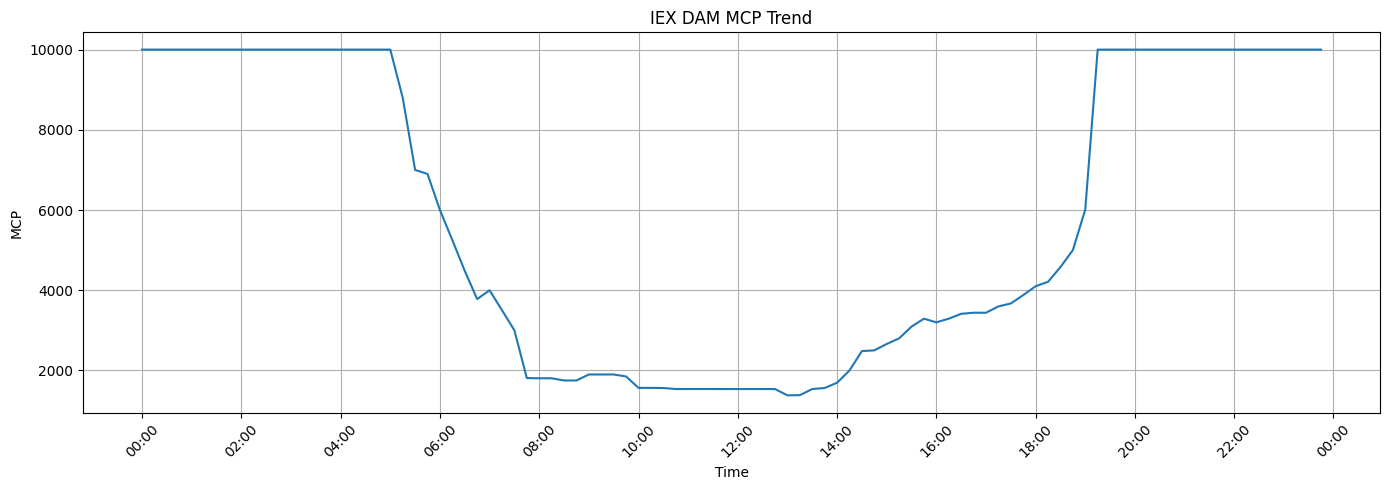

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["mcp_(rs/mwh)_*"])

plt.title("IEX DAM MCP Trend")
plt.xlabel("Time")
plt.ylabel("MCP")

# Better time formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [53]:
df.to_csv("../exports/cleaned_dam_data.csv", index=False)